In [56]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,test_size=0.5, random_state=42, stratify=y_temp)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1078, 64)
(359, 64)
(360, 64)


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [59]:
import numpy as np

D = 64
H = 128
C = 10

np.random.seed(42)

W1 = np.random.randn(D, H) * 0.01
b1 = np.zeros(H)

W2 = np.random.randn(H, C) * 0.01
b2 = np.zeros(C)

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)

def cross_entropy_loss(P, y):
    N = P.shape[0]
    log_ll = -np.log(P[np.arange(N), y])
    loss = np.mean(log_ll)
    return loss

def forward(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    P = softmax(Z2)
    cc = (X, Z1, A1, Z2, P)
    return P, cc

def backward(cache, y):
    global W1, W2
    X, Z1, A1, Z2, P = cache
    N = X.shape[0]

    Y = np.zeros_like(P)
    Y[np.arange(N), y] = 1
    dZ2 = (P - Y) / N
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_grad(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0)

    print("dW1:", dW1.shape)
    print("db1:", db1.shape)
    print("dW2:", dW2.shape)
    print("db2:", db2.shape)

    return dW1, db1, dW2, db2

W1 shape: (64, 128)
b1 shape: (128,)
W2 shape: (128, 10)
b2 shape: (10,)


In [60]:
lr = 0.01
epochs = 400
batch_size = 64

train_losses = []

for epoch in range(epochs):

    indices = np.random.permutation(len(X_train))

    X_train = X_train[indices]
    y_train = y_train[indices]

    for i in range(0, len(X_train), batch_size):

        Xb = X_train[i:i+batch_size]
        yb = y_train[i:i+batch_size]

        P, cache = forward(Xb)

        loss = cross_entropy_loss(P, yb)

        dW1, db1, dW2, db2 = backward(cache, yb)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    train_losses.append(loss)

    print("epoch:", epoch + 1, "loss:", loss)

def accuracy(X, y):
    P, _ = forward(X)
    y_pred = np.argmax(P, axis=1)
    return np.mean(y_pred == y)

train_acc = accuracy(X_train, y_train)
val_acc = accuracy(X_val, y_val)
test_acc = accuracy(X_test, y_test)

print("\nTrain Acc:", train_acc)
print("Val Acc:", val_acc)
print("Test Acc:", test_acc)

dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
epoch: 1 loss: 2.300187511744749
dW1: (64, 128)
db1: (128,)
dW2: (128, 10)
db2: (10,)
dW1: (64, 128

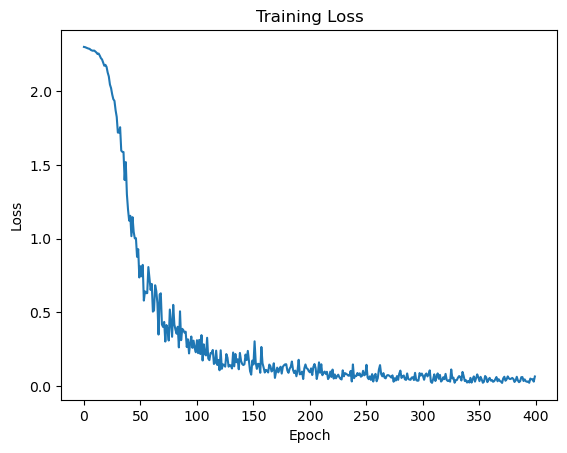

In [61]:
import matplotlib.pyplot as plt
import os

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

os.makedirs(os.path.join("resources", "pics"), exist_ok=True)
plot_path = os.path.join("resources", "pics", "lab3.png")
plt.savefig(plot_path, dpi=150)

plt.show()